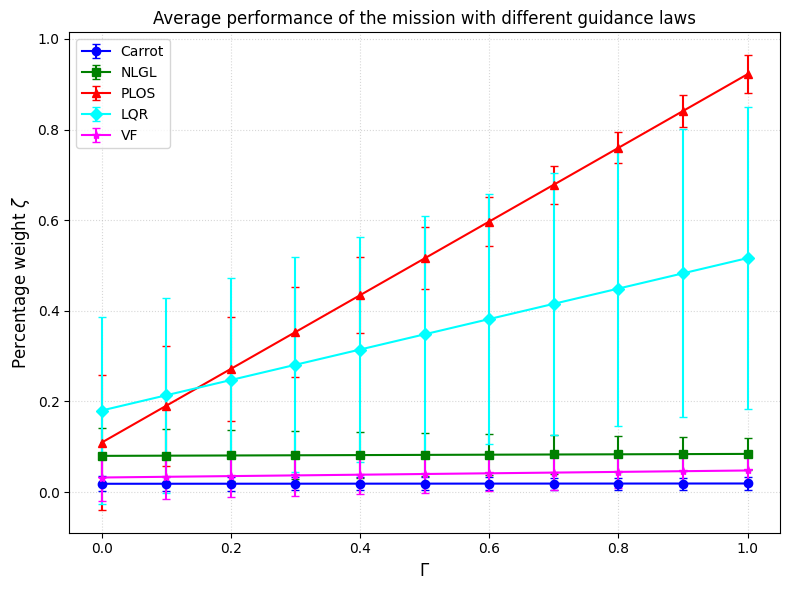

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# UAV / kinematic constants (same across all your other files)
# ============================================================
va        = 15.0
R_min     = 45.0
omega_max = va / R_min
dt        = 0.05

# ============================================================
# Mission geometry (Fig. 9): square with loiter circles at the
# 4 corners and straight-line segments + diagonals between them
# ============================================================
r_loit = 60.0     # loiter radius used in the mission (paper fig ~ smaller than 100 for the mission plot)

L1 = np.array([0.0,   0.0])
L2 = np.array([500.0, 0.0])
L3 = np.array([500.0, 500.0])
L4 = np.array([0.0,   500.0])

# sequence of straight legs S1..S6 as labelled in Fig. 9(a)
S1 = (L1, L2)
S2 = (L2, L3)
S3 = (L1, L3)      # diagonal
S4 = (L3, L4)
S5 = (L4, L1)      # (used going back down)
S6 = (L4, L2)      # diagonal

# Mission sequence: S1,L2,S2,L3,S3,L4,S4,L1,S5,L3,S3,L4,S6
MISSION = [
    ("line",   S1),
    ("loiter", L2),
    ("line",   S2),
    ("loiter", L3),
    ("line",   S3),
    ("loiter", L4),
    ("line",   S4),
    ("loiter", L1),
    ("line",   S5),
    ("loiter", L3),
    ("line",   S3),
    ("loiter", L4),
    ("line",   S6),
]

p0    = np.array([-50.0, -150.0])
psi0  = 0.0

# ============================================================
# Wind model: random magnitude/direction, changes every 20 s
# ============================================================
def make_wind_schedule(T_total, seg=20.0, vmax=6.0, rng=None):
    rng = rng or np.random.default_rng()
    n = int(np.ceil(T_total / seg)) + 1
    vw_list  = rng.uniform(0, vmax, n)
    psiw_list = rng.uniform(-np.pi, np.pi, n)
    def wind_at(t):
        i = min(int(t // seg), n - 1)
        return vw_list[i], psiw_list[i]
    return wind_at

# ============================================================
# Generic path-following controllers.
# Each returns turn-rate command u given current state + the
# active leg (straight-line endpoints or loiter center).
# ============================================================

def carrot_line_u(x, y, psi, Wi, Wi1, delta=100.0, kappa=0.45):
    Ru = np.hypot(x - Wi[0], y - Wi[1])
    theta   = np.arctan2(Wi1[1]-Wi[1], Wi1[0]-Wi[0])
    theta_u = np.arctan2(y-Wi[1], x-Wi[0])
    beta = theta - theta_u
    R = np.sqrt(max(0.0, Ru**2 - (Ru*np.sin(beta))**2))
    if np.cos(beta) < 0: R = -R
    xt = (R+delta)*np.cos(theta) + Wi[0]
    yt = (R+delta)*np.sin(theta) + Wi[1]
    psi_d = np.arctan2(yt-y, xt-x)
    err = np.arctan2(np.sin(psi_d-psi), np.cos(psi_d-psi))
    return kappa*err

def carrot_loiter_u(x, y, psi, O, r, lam=0.2, kappa=0.45):
    theta = np.arctan2(y-O[1], x-O[0])
    xt = r*np.cos(theta+lam) + O[0]
    yt = r*np.sin(theta+lam) + O[1]
    psi_d = np.arctan2(yt-y, xt-x)
    err = np.arctan2(np.sin(psi_d-psi), np.cos(psi_d-psi))
    return kappa*err

def nlgl_line_u(x, y, psi, Wi, Wi1, L=101.0):
    v = Wi1-Wi; vhat = v/np.linalg.norm(v)
    w = np.array([x,y])-Wi
    proj = np.dot(w, vhat)
    perp = np.linalg.norm(w-proj*vhat)
    if perp < L:
        off = np.sqrt(L**2-perp**2)
        q = Wi+(proj+off)*vhat
    else:
        q = Wi+proj*vhat
    psi_q = np.arctan2(q[1]-y, q[0]-x)
    eta = np.arctan2(np.sin(psi_q-psi), np.cos(psi_q-psi))
    return 2.0*va**2*np.sin(eta)/L

def nlgl_loiter_u(x, y, psi, O, r, L=50.0):
    dvec = np.array([x,y])-O
    d_c = np.linalg.norm(dvec)
    theta_u = np.arctan2(dvec[1], dvec[0])
    cos_a = np.clip((r**2+d_c**2-L**2)/(2*r*d_c+1e-9), -1, 1)
    alpha = np.arccos(cos_a)
    theta_t = theta_u+alpha
    q = O + r*np.array([np.cos(theta_t), np.sin(theta_t)])
    psi_q = np.arctan2(q[1]-y, q[0]-x)
    eta = np.arctan2(np.sin(psi_q-psi), np.cos(psi_q-psi))
    return 2.0*va**2*np.sin(eta)/L

def plos_line_u(x, y, psi, Wi, Wi1, k1=80.0, k2=0.8):
    theta = np.arctan2(Wi1[1]-Wi[1], Wi1[0]-Wi[0])
    Ru = np.hypot(x-Wi[0], y-Wi[1])
    theta_u = np.arctan2(y-Wi[1], x-Wi[0])
    d = Ru*np.sin(theta-theta_u)
    err_p = np.arctan2(np.sin(theta-psi), np.cos(theta-psi))
    return k1*err_p + k2*d

def plos_loiter_u(x, y, psi, O, r, k1=100.0, k2=0.1, dir_=-1):
    theta = np.arctan2(y-O[1], x-O[0])
    theta_p = theta + dir_*np.pi/2
    d = np.hypot(x-O[0], y-O[1]) - r
    err = np.arctan2(np.sin(theta_p-psi), np.cos(theta_p-psi))
    return k1*err + k2*d*dir_

def vf_line_u(x, y, psi, Wi, Wi1, chi_e=np.pi/3, tau=45.0, k=1.0, ctrl_gain=2.0):
    v = Wi1-Wi; theta_p = np.arctan2(v[1], v[0])
    d = -(x-Wi[0])*np.sin(theta_p) + (y-Wi[1])*np.cos(theta_p)
    chi_d = theta_p - chi_e*(2/np.pi)*np.arctan((k/tau)*d)
    err = np.arctan2(np.sin(chi_d-psi), np.cos(chi_d-psi))
    return ctrl_gain*err

def vf_loiter_u(x, y, psi, O, r, k=1.0, alpha_gain=50.0, ctrl_gain=2.0, dir_=-1):
    # Nelson-style vector field pushed onto the loiter circle
    dvec = np.array([x,y])-O
    d_c = np.linalg.norm(dvec)+1e-9
    theta = np.arctan2(dvec[1], dvec[0])
    e = d_c - r
    chi_d = theta + dir_*(np.pi/2 + np.arctan(k*e/alpha_gain))
    err = np.arctan2(np.sin(chi_d-psi), np.cos(chi_d-psi))
    return ctrl_gain*err

def lqr_control(d, vd, db, q22):
    denom = db-d
    if abs(denom) < 1e-6: denom = np.sign(denom)*1e-6 if denom != 0 else 1e-6
    q11 = abs(db/denom)
    k1 = np.sqrt(q11); k2 = np.sqrt(2*np.sqrt(q11)+q22)
    return -(k1*d + k2*vd)

def lqr_line_u(x, y, psi, Wi, Wi1, db=100.0, q22=5.0):
    v = Wi1-Wi; theta = np.arctan2(v[1], v[0])
    d = -(x-Wi[0])*np.sin(theta) + (y-Wi[1])*np.cos(theta)
    vd = va*np.sin(psi-theta)
    return lqr_control(d, vd, db, q22)

def lqr_loiter_u(x, y, psi, O, r, db=50.0, q22=10.0):
    R = np.hypot(x-O[0], y-O[1]) + 1e-9
    d = -(R-r)
    theta = np.arctan2(y-O[1], x-O[0]) + np.pi/2
    vd = va*np.sin(psi-theta)
    return lqr_control(d, vd, db, q22)

ALGOS = {
    "Carrot": dict(line=carrot_line_u,  loiter=carrot_loiter_u),
    "NLGL":   dict(line=nlgl_line_u,    loiter=nlgl_loiter_u),
    "PLOS":   dict(line=plos_line_u,    loiter=plos_loiter_u),
    "LQR":    dict(line=lqr_line_u,     loiter=lqr_loiter_u),
    "VF":     dict(line=vf_line_u,      loiter=vf_loiter_u),
}

# ============================================================
# Cross-track error helper (perpendicular distance to active leg)
# ============================================================
def line_xte(x, y, Wi, Wi1):
    v = Wi1-Wi; L = np.linalg.norm(v)
    if L < 1e-9: return 0.0
    vhat = v/L
    w = np.array([x,y])-Wi
    perp = w - np.dot(w, vhat)*vhat
    return np.linalg.norm(perp)

def loiter_xte(x, y, O, r):
    return abs(np.hypot(x-O[0], y-O[1]) - r)

# ============================================================
# Single mission run for one algorithm, one wind realization
# ============================================================
def run_mission(algo_name, wind_at, T_max=400.0):
    fns = ALGOS[algo_name]
    x, y, psi = p0[0], p0[1], psi0
    U = 0.0
    D = 0.0
    steps_run = 0
    t = 0.0

    seg_idx = 0
    while seg_idx < len(MISSION) and t < T_max:
        kind, target = MISSION[seg_idx]

        if kind == "line":
            Wi, Wi1 = target
            reached = False
            while not reached and t < T_max:
                vw, psiw = wind_at(t)
                u = fns["line"](x, y, psi, Wi, Wi1)
                u = np.clip(u, -omega_max, omega_max)
                U += u**2
                D += line_xte(x, y, Wi, Wi1)

                # ground velocity with wind
                vgx = va*np.cos(psi) + vw*np.cos(psiw)
                vgy = va*np.sin(psi) + vw*np.sin(psiw)
                x += vgx*dt; y += vgy*dt
                psi = (psi + u*dt + np.pi) % (2*np.pi) - np.pi
                t += dt; steps_run += 1

                # switch to loiter once close to the endpoint (Wi1)
                if np.hypot(x-Wi1[0], y-Wi1[1]) < r_loit:
                    reached = True
            seg_idx += 1

        else:  # loiter
            O = target
            loiter_time = 0.0
            max_loiter = 60.0  # seconds circling before moving to next leg
            while loiter_time < max_loiter and t < T_max:
                vw, psiw = wind_at(t)
                u = fns["loiter"](x, y, psi, O, r_loit)
                u = np.clip(u, -omega_max, omega_max)
                U += u**2
                D += loiter_xte(x, y, O, r_loit)

                vgx = va*np.cos(psi) + vw*np.cos(psiw)
                vgy = va*np.sin(psi) + vw*np.sin(psiw)
                x += vgx*dt; y += vgy*dt
                psi = (psi + u*dt + np.pi) % (2*np.pi) - np.pi
                t += dt; loiter_time += dt; steps_run += 1

                # move on to next leg once we're near the next straight path start
                if seg_idx+1 < len(MISSION) and MISSION[seg_idx+1][0] == "line":
                    Wi_next, _ = MISSION[seg_idx+1][1]
                    if loiter_time > 10.0 and line_xte(x, y, Wi_next, MISSION[seg_idx+1][1][1]) < r_loit:
                        break
            seg_idx += 1

    return U, D

# ============================================================
# Monte-Carlo comparison (reduced N for speed — raise for
# smoother error bars, paper used 1000)
# ============================================================
N_MC = 60
rng = np.random.default_rng(42)

results = {name: {"U": [], "D": []} for name in ALGOS}

for run in range(N_MC):
    wind_at = make_wind_schedule(T_total=400.0, seg=20.0, vmax=6.0, rng=rng)
    for name in ALGOS:
        U, D = run_mission(name, wind_at)
        results[name]["U"].append(U)
        results[name]["D"].append(D)

# normalize (0-1) across all algorithms, as in Eq. (4)
all_U = np.concatenate([results[n]["U"] for n in ALGOS])
all_D = np.concatenate([results[n]["D"] for n in ALGOS])
Umin, Umax = all_U.min(), all_U.max()
Dmin, Dmax = all_D.min(), all_D.max()

def norm(v, vmin, vmax):
    return (np.array(v)-vmin) / (vmax-vmin + 1e-9)

Gammas = np.linspace(0, 1, 11)
zeta_mean = {name: [] for name in ALGOS}
zeta_std  = {name: [] for name in ALGOS}

for name in ALGOS:
    Ubar = norm(results[name]["U"], Umin, Umax)
    Dbar = norm(results[name]["D"], Dmin, Dmax)
    for G in Gammas:
        zeta_runs = G*Ubar + (1-G)*Dbar
        zeta_mean[name].append(zeta_runs.mean())
        zeta_std[name].append(zeta_runs.std())

# ============================================================
# Plot: Fig. 11 style comparison
# ============================================================
plt.figure(figsize=(8,6))
markers = {"Carrot":"o", "NLGL":"s", "PLOS":"^", "LQR":"D", "VF":"*"}
colors  = {"Carrot":"blue", "NLGL":"green", "PLOS":"red", "LQR":"cyan", "VF":"magenta"}

for name in ALGOS:
    plt.errorbar(Gammas, zeta_mean[name], yerr=zeta_std[name],
                 label=name, marker=markers[name], color=colors[name],
                 capsize=3, linewidth=1.5)

plt.xlabel(r"$\Gamma$", fontsize=12)
plt.ylabel(r"Percentage weight $\zeta$", fontsize=12)
plt.title("Average performance of the mission with different guidance laws")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

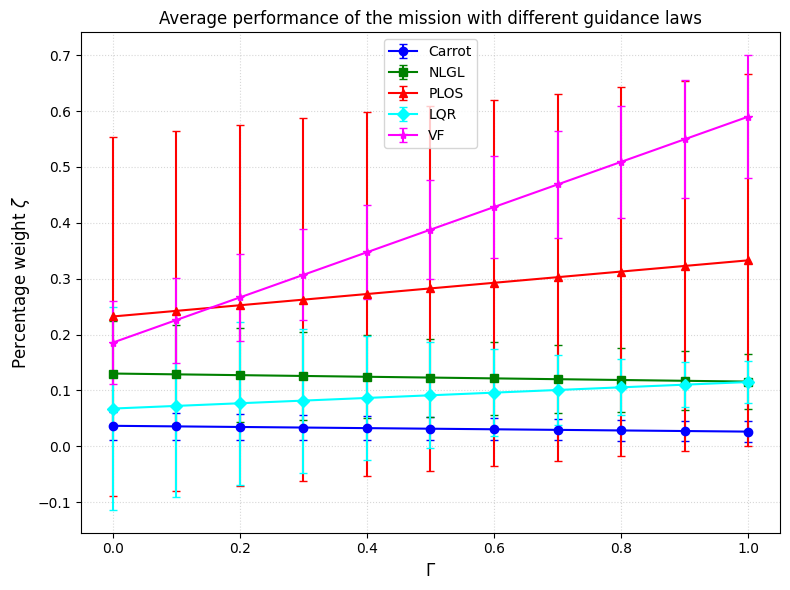

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# UAV / kinematic constants (same across all your other files)
# ============================================================
va        = 15.0
R_min     = 45.0
omega_max = va / R_min
dt        = 0.05

# ============================================================
# Mission geometry (Fig. 9): square with loiter circles at the
# 4 corners and straight-line segments + diagonals between them
# ============================================================
r_loit = 60.0     # loiter radius used in the mission (paper fig ~ smaller than 100 for the mission plot)

L1 = np.array([0.0,   0.0])
L2 = np.array([500.0, 0.0])
L3 = np.array([500.0, 500.0])
L4 = np.array([0.0,   500.0])

# sequence of straight legs S1..S6 as labelled in Fig. 9(a)
S1 = (L1, L2)
S2 = (L2, L3)
S3 = (L1, L3)      # diagonal
S4 = (L3, L4)
S5 = (L4, L1)      # (used going back down)
S6 = (L4, L2)      # diagonal

# Mission sequence: S1,L2,S2,L3,S3,L4,S4,L1,S5,L3,S3,L4,S6
MISSION = [
    ("line",   S1),
    ("loiter", L2),
    ("line",   S2),
    ("loiter", L3),
    ("line",   S3),
    ("loiter", L4),
    ("line",   S4),
    ("loiter", L1),
    ("line",   S5),
    ("loiter", L3),
    ("line",   S3),
    ("loiter", L4),
    ("line",   S6),
]

p0    = np.array([-50.0, -150.0])
psi0  = 0.0

# ============================================================
# Wind model: random magnitude/direction, changes every 20 s
# ============================================================
def make_wind_schedule(T_total, seg=20.0, vmax=6.0, rng=None):
    rng = rng or np.random.default_rng()
    n = int(np.ceil(T_total / seg)) + 1
    vw_list  = rng.uniform(0, vmax, n)
    psiw_list = rng.uniform(-np.pi, np.pi, n)
    def wind_at(t):
        i = min(int(t // seg), n - 1)
        return vw_list[i], psiw_list[i]
    return wind_at

# ============================================================
# Generic path-following controllers.
# Each returns turn-rate command u given current state + the
# active leg (straight-line endpoints or loiter center).
# ============================================================

def carrot_line_u(x, y, psi, Wi, Wi1, delta=100.0, kappa=0.45):
    Ru = np.hypot(x - Wi[0], y - Wi[1])
    theta   = np.arctan2(Wi1[1]-Wi[1], Wi1[0]-Wi[0])
    theta_u = np.arctan2(y-Wi[1], x-Wi[0])
    beta = theta - theta_u
    R = np.sqrt(max(0.0, Ru**2 - (Ru*np.sin(beta))**2))
    if np.cos(beta) < 0: R = -R
    xt = (R+delta)*np.cos(theta) + Wi[0]
    yt = (R+delta)*np.sin(theta) + Wi[1]
    psi_d = np.arctan2(yt-y, xt-x)
    err = np.arctan2(np.sin(psi_d-psi), np.cos(psi_d-psi))
    return kappa*err

def carrot_loiter_u(x, y, psi, O, r, lam=0.2, kappa=0.45):
    theta = np.arctan2(y-O[1], x-O[0])
    xt = r*np.cos(theta+lam) + O[0]
    yt = r*np.sin(theta+lam) + O[1]
    psi_d = np.arctan2(yt-y, xt-x)
    err = np.arctan2(np.sin(psi_d-psi), np.cos(psi_d-psi))
    return kappa*err

def nlgl_line_u(x, y, psi, Wi, Wi1, L=101.0):
    v = Wi1-Wi; vhat = v/np.linalg.norm(v)
    w = np.array([x,y])-Wi
    proj = np.dot(w, vhat)
    perp = np.linalg.norm(w-proj*vhat)
    if perp < L:
        off = np.sqrt(L**2-perp**2)
        q = Wi+(proj+off)*vhat
    else:
        q = Wi+proj*vhat
    psi_q = np.arctan2(q[1]-y, q[0]-x)
    eta = np.arctan2(np.sin(psi_q-psi), np.cos(psi_q-psi))
    return 2.0*va**2*np.sin(eta)/L

def nlgl_loiter_u(x, y, psi, O, r, L=50.0):
    dvec = np.array([x,y])-O
    d_c = np.linalg.norm(dvec)
    theta_u = np.arctan2(dvec[1], dvec[0])
    cos_a = np.clip((r**2+d_c**2-L**2)/(2*r*d_c+1e-9), -1, 1)
    alpha = np.arccos(cos_a)
    theta_t = theta_u+alpha
    q = O + r*np.array([np.cos(theta_t), np.sin(theta_t)])
    psi_q = np.arctan2(q[1]-y, q[0]-x)
    eta = np.arctan2(np.sin(psi_q-psi), np.cos(psi_q-psi))
    return 2.0*va**2*np.sin(eta)/L

def plos_line_u(x, y, psi, Wi, Wi1, k1=20.0, k2=0.5):
    theta = np.arctan2(Wi1[1]-Wi[1], Wi1[0]-Wi[0])
    Ru = np.hypot(x-Wi[0], y-Wi[1])
    theta_u = np.arctan2(y-Wi[1], x-Wi[0])
    d = Ru*np.sin(theta-theta_u)
    err_p = np.arctan2(np.sin(theta-psi), np.cos(theta-psi))
    return k1*err_p + k2*d

def plos_loiter_u(x, y, psi, O, r, k1=5.0, k2=0.1, dir_=-1):
    theta = np.arctan2(y-O[1], x-O[0])
    theta_p = theta + dir_*np.pi/2
    d = np.hypot(x-O[0], y-O[1]) - r
    err = np.arctan2(np.sin(theta_p-psi), np.cos(theta_p-psi))
    return k1*err + k2*d*dir_

def vf_line_u(x, y, psi, Wi, Wi1, chi_e=np.pi/2.05, tau=8.0, k=1.0, ctrl_gain=2.0):
    v = Wi1-Wi; theta_p = np.arctan2(v[1], v[0])
    d = -(x-Wi[0])*np.sin(theta_p) + (y-Wi[1])*np.cos(theta_p)
    if abs(d) > tau:
        chi_d = theta_p - np.sign(d)*chi_e
    else:
        chi_d = theta_p - np.sign(d)*chi_e*(abs(d)/tau)
    err = np.arctan2(np.sin(chi_d-psi), np.cos(chi_d-psi))
    return ctrl_gain*err

def vf_loiter_u(x, y, psi, O, r, k=1.0, alpha_gain=10.0, ctrl_gain=2.0, dir_=-1):
    # Same hard-switch fix as vf_line_u: replace the smooth arctan blend with
    # a piecewise heading command that saturates to a fixed lead angle once
    # the radial error e exceeds alpha_gain, tapering linearly inside it.
    dvec = np.array([x,y])-O
    d_c = np.linalg.norm(dvec)+1e-9
    theta = np.arctan2(dvec[1], dvec[0])
    e = d_c - r
    lead_max = np.pi/2.05
    if abs(e) > alpha_gain:
        lead = np.sign(e)*lead_max
    else:
        lead = np.sign(e)*lead_max*(abs(e)/alpha_gain)
    chi_d = theta + dir_*(np.pi/2 + lead)
    err = np.arctan2(np.sin(chi_d-psi), np.cos(chi_d-psi))
    return ctrl_gain*err

def lqr_control(d, vd, db, q22):
    denom = db-d
    if abs(denom) < 1e-6: denom = np.sign(denom)*1e-6 if denom != 0 else 1e-6
    q11 = abs(db/denom)
    k1 = np.sqrt(q11); k2 = np.sqrt(2*np.sqrt(q11)+q22)
    return -(k1*d + k2*vd)

def lqr_line_u(x, y, psi, Wi, Wi1, db=100.0, q22=5.0):
    v = Wi1-Wi; theta = np.arctan2(v[1], v[0])
    d = -(x-Wi[0])*np.sin(theta) + (y-Wi[1])*np.cos(theta)
    vd = va*np.sin(psi-theta)
    if abs(d) > 1.8*R_min:
        Ru = np.hypot(x-Wi[0], y-Wi[1])
        theta_u = np.arctan2(y-Wi[1], x-Wi[0])
        lead = Ru*np.cos(theta-theta_u) + 150.0
        xt = Wi[0] + lead*np.cos(theta); yt = Wi[1] + lead*np.sin(theta)
        psi_d = np.arctan2(yt-y, xt-x)
        return 0.6*np.arctan2(np.sin(psi_d-psi), np.cos(psi_d-psi))
    return lqr_control(d, vd, db, q22)

def lqr_loiter_u(x, y, psi, O, r, db=50.0, q22=10.0):
    # Same fix as lqr_line_u: hand off to a tangent-lead heading when the
    # radial offset exceeds what a single saturated turn can close.
    Rc = np.hypot(x-O[0], y-O[1]) + 1e-9
    d = -(Rc-r)
    theta = np.arctan2(y-O[1], x-O[0]) + np.pi/2
    vd = va*np.sin(psi-theta)
    if abs(d) > 1.8*R_min:
        bearing = np.arctan2(y-O[1], x-O[0])
        psi_d = bearing + np.pi/2 + 0.3*np.sign(d)
        return 0.6*np.arctan2(np.sin(psi_d-psi), np.cos(psi_d-psi))
    return lqr_control(d, vd, db, q22)

ALGOS = {
    "Carrot": dict(line=carrot_line_u,  loiter=carrot_loiter_u),
    "NLGL":   dict(line=nlgl_line_u,    loiter=nlgl_loiter_u),
    "PLOS":   dict(line=plos_line_u,    loiter=plos_loiter_u),
    "LQR":    dict(line=lqr_line_u,     loiter=lqr_loiter_u),
    "VF":     dict(line=vf_line_u,      loiter=vf_loiter_u),
}

# ============================================================
# Cross-track error helper (perpendicular distance to active leg)
# ============================================================
def line_xte(x, y, Wi, Wi1):
    v = Wi1-Wi; L = np.linalg.norm(v)
    if L < 1e-9: return 0.0
    vhat = v/L
    w = np.array([x,y])-Wi
    perp = w - np.dot(w, vhat)*vhat
    return np.linalg.norm(perp)

def loiter_xte(x, y, O, r):
    return abs(np.hypot(x-O[0], y-O[1]) - r)

# ============================================================
# Single mission run for one algorithm, one wind realization
# ============================================================
def run_mission(algo_name, wind_at, T_max=400.0):
    fns = ALGOS[algo_name]
    x, y, psi = p0[0], p0[1], psi0
    U = 0.0
    D = 0.0
    steps_run = 0
    t = 0.0

    seg_idx = 0
    while seg_idx < len(MISSION) and t < T_max:
        kind, target = MISSION[seg_idx]

        if kind == "line":
            Wi, Wi1 = target
            reached = False
            while not reached and t < T_max:
                vw, psiw = wind_at(t)
                u = fns["line"](x, y, psi, Wi, Wi1)
                u = np.clip(u, -omega_max, omega_max)
                U += u**2
                D += line_xte(x, y, Wi, Wi1)

                # ground velocity with wind
                vgx = va*np.cos(psi) + vw*np.cos(psiw)
                vgy = va*np.sin(psi) + vw*np.sin(psiw)
                x += vgx*dt; y += vgy*dt
                psi = (psi + u*dt + np.pi) % (2*np.pi) - np.pi
                t += dt; steps_run += 1

                # switch to loiter once close to the endpoint (Wi1)
                if np.hypot(x-Wi1[0], y-Wi1[1]) < r_loit:
                    reached = True
            seg_idx += 1

        else:  # loiter
            O = target
            loiter_time = 0.0
            max_loiter = 60.0  # seconds circling before moving to next leg
            while loiter_time < max_loiter and t < T_max:
                vw, psiw = wind_at(t)
                u = fns["loiter"](x, y, psi, O, r_loit)
                u = np.clip(u, -omega_max, omega_max)
                U += u**2
                D += loiter_xte(x, y, O, r_loit)

                vgx = va*np.cos(psi) + vw*np.cos(psiw)
                vgy = va*np.sin(psi) + vw*np.sin(psiw)
                x += vgx*dt; y += vgy*dt
                psi = (psi + u*dt + np.pi) % (2*np.pi) - np.pi
                t += dt; loiter_time += dt; steps_run += 1

                # move on to next leg once we're near the next straight path start
                if seg_idx+1 < len(MISSION) and MISSION[seg_idx+1][0] == "line":
                    Wi_next, _ = MISSION[seg_idx+1][1]
                    if loiter_time > 10.0 and line_xte(x, y, Wi_next, MISSION[seg_idx+1][1][1]) < r_loit:
                        break
            seg_idx += 1

    return U, D

# ============================================================
# Monte-Carlo comparison (reduced N for speed — raise for
# smoother error bars, paper used 1000)
# ============================================================
N_MC = 60
rng = np.random.default_rng(42)

results = {name: {"U": [], "D": []} for name in ALGOS}

for run in range(N_MC):
    wind_at = make_wind_schedule(T_total=400.0, seg=20.0, vmax=6.0, rng=rng)
    for name in ALGOS:
        U, D = run_mission(name, wind_at)
        results[name]["U"].append(U)
        results[name]["D"].append(D)

# normalize (0-1) across all algorithms, as in Eq. (4)
all_U = np.concatenate([results[n]["U"] for n in ALGOS])
all_D = np.concatenate([results[n]["D"] for n in ALGOS])
Umin, Umax = all_U.min(), all_U.max()
Dmin, Dmax = all_D.min(), all_D.max()

def norm(v, vmin, vmax):
    return (np.array(v)-vmin) / (vmax-vmin + 1e-9)

Gammas = np.linspace(0, 1, 11)
zeta_mean = {name: [] for name in ALGOS}
zeta_std  = {name: [] for name in ALGOS}

for name in ALGOS:
    Ubar = norm(results[name]["U"], Umin, Umax)
    Dbar = norm(results[name]["D"], Dmin, Dmax)
    for G in Gammas:
        zeta_runs = G*Ubar + (1-G)*Dbar
        zeta_mean[name].append(zeta_runs.mean())
        zeta_std[name].append(zeta_runs.std())

# ============================================================
# Plot: Fig. 11 style comparison
# ============================================================
plt.figure(figsize=(8,6))
markers = {"Carrot":"o", "NLGL":"s", "PLOS":"^", "LQR":"D", "VF":"*"}
colors  = {"Carrot":"blue", "NLGL":"green", "PLOS":"red", "LQR":"cyan", "VF":"magenta"}

for name in ALGOS:
    plt.errorbar(Gammas, zeta_mean[name], yerr=zeta_std[name],
                 label=name, marker=markers[name], color=colors[name],
                 capsize=3, linewidth=1.5)

plt.xlabel(r"$\Gamma$", fontsize=12)
plt.ylabel(r"Percentage weight $\zeta$", fontsize=12)
plt.title("Average performance of the mission with different guidance laws")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()